<a href="https://colab.research.google.com/github/huutai-cmyk/Homework-1/blob/main/buoi5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import cv2
import numpy as np
import matplotlib.pyplot as plt
cifar10_classes = ['Máy bay (airplane)','Ô tô (automobile)','Chim (bird)', 'Mèo (cat)',
                   'Nai (deer)','chó (dog)', 'ếch (frog)', 'Ngựa (horse)','tàu thủy (ship)','Xe tải (truck)']


In [ ]:
!pip install numpy

Initial y_train shape after loading: (50000, 1)
Initial y_test shape after loading: (10000, 1)


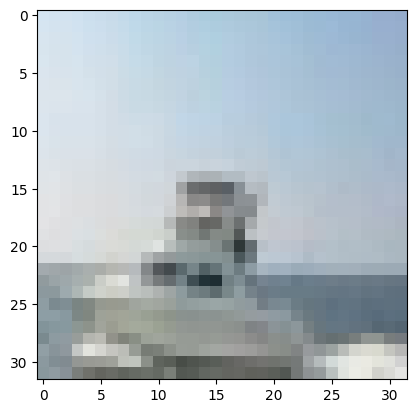

In [ ]:
from keras.datasets import cifar10
(x_train, y_train), (x_test, y_test)=cifar10.load_data()

# Print shapes after loading to verify
print(f"Initial y_train shape after loading: {y_train.shape}")
print(f"Initial y_test shape after loading: {y_test.shape}")

import matplotlib.pyplot as plt
plt.imshow(x_train[100])
# plt.imshow(digit, cmap=plt.cm.binary) # 'digit' is not defined, commented out for now
plt.show()

In [ ]:
x_train=x_train.astype('float32')/255
x_test=x_test.astype('float32')/255
from keras.utils import to_categorical

# Debug: Print shape before processing
print(f"y_train shape before processing: {y_train.shape}")
print(f"y_test shape before processing: {y_test.shape}")

# Ensure y_train and y_test are 1D arrays of labels before one-hot encoding
y_train_reshaped = y_train.reshape(-1)
y_test_reshaped = y_test.reshape(-1)

# Debug: Print shape after reshaping
print(f"y_train shape after reshape: {y_train_reshaped.shape}")
print(f"y_test shape after reshape: {y_test_reshaped.shape}")

y_train = to_categorical(y_train_reshaped, num_classes=10)
y_test = to_categorical(y_test_reshaped, num_classes=10)

# Debug: Print shape after to_categorical
print(f"y_train shape after to_categorical: {y_train.shape}")
print(f"y_test shape after to_categorical: {y_test.shape}")

y_train shape before processing: (50000, 1)
y_test shape before processing: (10000, 1)
y_train shape after reshape: (50000,)
y_test shape after reshape: (10000,)
y_train shape after to_categorical: (50000, 10)
y_test shape after to_categorical: (10000, 10)


In [ ]:
from  keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
model=Sequential()
model.add(Conv2D(32,(3,3), activation='relu',padding='same', input_shape=(32,32,3)))#au khi tích chập thì vẫn như vậy, 1 là 1 kênh màu
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64,(3,3), activation='relu',padding='same'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64,(3,3), activation='relu',padding='same'))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<bound method Model.summary of <Sequential name=sequential, built=True>>

In [ ]:
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['acc']) #biên dịch

In [ ]:
model.fit(x_train,y_train,epochs=5)

NameError: name 'model' is not defined

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


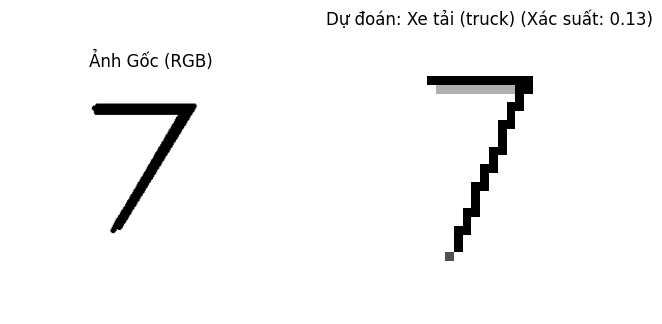

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# The original error: You need to provide a valid path to an image file here.
# Example: img = cv2.imread('/content/path/to/your/image.jpg')
# Ensure the image file exists and the path is correct.
img = cv2.imread('/content/Ảnh chụp màn hình 2026-05-20 091801.png')

# It's good practice to check if the image was loaded successfully
if img is None:
    print("Error: Could not load image. Please provide a valid image path.")
else:
    # Convert BGR to RGB for consistent processing with matplotlib
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize the image to 32x32 pixels to match CIFAR-10 dimensions
    img_resized = cv2.resize(img_rgb, (32, 32))

    # Normalize pixel values to be between 0 and 1
    img_ready = img_resized.astype('float32') / 255.0

    # Reshape for prediction (1 sample, 32x32 pixels, 3 channels for RGB)
    img_ready = img_ready.reshape(1, 32, 32, 3)

    # Ensure 'model' is defined and compiled before running this cell.
    # Perform prediction
    preds = model.predict(img_ready)

    # Get the predicted class index
    predicted_class_index = np.argmax(preds)

    # Use the defined cifar10_classes for a readable prediction label
    # Ensure cifar10_classes list is defined in an executed cell (e.g., E2vFERq3RlUo)
    predicted_label = cifar10_classes[predicted_class_index]

    # Plotting the images and prediction
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Ảnh Gốc (RGB)')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_resized) # Show the resized image that was fed to the model
    plt.title(f'Dự đoán: {predicted_label} (Xác suất: {preds[0, predicted_class_index]:.2f})')
    plt.axis('off')
    plt.show()

### Tải dữ liệu từ Google Drive

Để tải dữ liệu từ Google Drive, bạn cần thực hiện các bước sau:

1.  **Mount Google Drive**: Chạy ô mã dưới đây để kết nối Colab với Google Drive của bạn. Bạn sẽ cần xác thực.
2.  **Chỉ định đường dẫn tệp**: Sau khi Drive được mount, bạn có thể truy cập các tệp của mình trong thư mục `/content/gdrive/My Drive/`. Hãy thay thế `'path/to/your/file_on_drive.csv'` bằng đường dẫn thực tế đến tệp của bạn trên Google Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


Sau khi Google Drive đã được mount, bạn có thể đọc tệp của mình. Ví dụ, nếu đó là một tệp CSV, bạn có thể sử dụng pandas:

In [ ]:
import pandas as pd

# Thay thế bằng đường dẫn thực tế đến tệp của bạn trên Google Drive
drive_file_path = '/content/gdrive/My Drive/path/to/your/file_on_drive.csv'

try:
    df_from_drive = pd.read_csv(drive_file_path)
    print(f"Đã tải {len(df_from_drive)} hàng từ Google Drive.")
    display(df_from_drive.head())
except FileNotFoundError:
    print(f"Lỗi: Không tìm thấy tệp tại đường dẫn: {drive_file_path}. Vui lòng kiểm tra lại đường dẫn.")
except Exception as e:
    print(f"Đã xảy ra lỗi khi đọc tệp: {e}")

Lỗi: Không tìm thấy tệp tại đường dẫn: /content/gdrive/My Drive/path/to/your/file_on_drive.csv. Vui lòng kiểm tra lại đường dẫn.


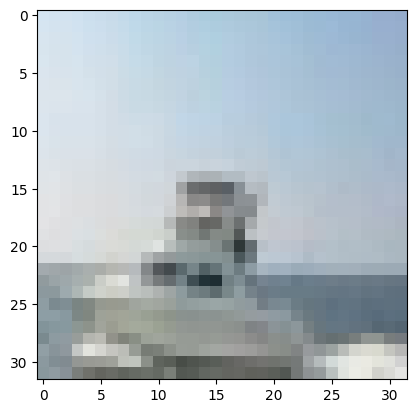

In [ ]:
#cifar10
from keras.datasets import cifar10
(x_train, y_train), (x_test, y_test)=cifar10.load_data()
import matplotlib.pyplot as plt
plt.imshow(x_train[100])
# plt.imshow(digit, cmap=plt.cm.binary) # 'digit' is not defined, commented out for now
plt.show()

In [ ]:
x_train=x_train.astype('float32')/255
x_test=x_test.astype('float32')/255
from keras.utils import to_categorical
y_train=to_categorical(y_train.reshape(-1), num_classes=10)
y_test=to_categorical(y_test.reshape(-1), num_classes=10)

In [ ]:
from keras.models import Sequential
from keras.layers import Dense,Conv2D,Flatten,MaxPooling2D
model=Sequential()
model.add(Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(32,32,3)))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,(3,3),activation='relu',padding='same'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64,(3,3),activation='relu',padding='same'))
model.add(Flatten())
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,178 (1.22 MB)

 Trainable params: 319,178 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='rmsprop',loss='categorical_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=20)

ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 50000
'y' sizes: 1000000


Nhận dạng khuôn mặt sinh viên


In [ ]:
from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_dir = '/content/drive/MyDrive/Ảnh Lớp IC'
img_width, img_height=280, 280
batch_size= 32
train_datagen = ImageDataGenerator(
    rescale= 1.0/255,
    rotation_range= 30,
    width_shift_range= 0.2,
    height_shift_range= 0.2,
    shear_range= 0.2,
    zoom_range= 0.2,
    horizontal_flip= True,
    fill_mode= 'nearest'
)



In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size= (img_width, img_height),
    batch_size= batch_size,
    class_mode= 'categorical'
)

Found 1398 images belonging to 34 classes.


In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential([
    Input(shape=(img_width, img_height, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(34, activation='softmax') # Changed from 8 to 34 to match the number of classes
])

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_generator, epochs=5)


Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 1114s 25s/step - accuracy: 0.0858 - loss: 4.2028
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.2318 - loss: 2.6032
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.4041 - loss: 1.9342
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.5222 - loss: 1.5755
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.5916 - loss: 1.2854


In [ ]:
model.save('ht.h5')
from keras.models import load_model
model = load_model('ht.h5')

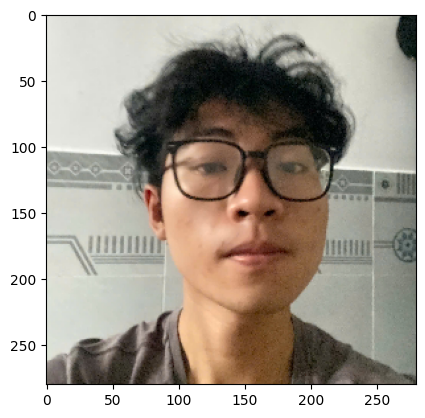

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Người tiên đoán:Trọng Phước


In [ ]:
from keras.utils import load_img
import numpy as np
path= '/content/z7869475993784_830d2d961647577eadaa3de091412202.jpg'
img=load_img(path,target_size=(280,280))
plt.imshow(img)
plt.show()
img = np.array(img)
img=img/255.0
img= img.reshape(1,img_width,img_height,3) # Corrected reshape dimensions
prediction=np.argmax(model.predict(img))
class_labels={v:k for k,v in train_generator.class_indices.items()}
person_name=class_labels[prediction]
print(f'Người tiên đoán:{person_name}')